Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.signal import butter, freqz
from scipy.signal import filtfilt

Loading files and data

In [49]:
#Path of the file to open
#path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/TAS1D48140076_2025-04-08_IMU.csv" #Donnees journee dec
#path_right_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/TAS1H46190341_(2025-04-08)-IMU.csv"#Donnees journee dec
#path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/TAS1D48140076_(2025-04-09)_test3-IMU.csv" # fichier de test
#path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_10_04_2025/TAS1H46190341_(2025-04-10)-IMU.csv" # enregistrement clemence
#path_right_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_10_04_2025/TAS1H46190449_(2025-04-10)-IMU.csv"# enregistrement clemence
#path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Louis_9h00_10h34.csv" #LOUIS
#path_right_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Louis_9h00_10h34.csv"#LOUIS
path_left_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1D48140076_(2025-04-16)-IMU_Adele_13h48_15h18.csv" #ADELE
path_right_wrist = "C:/Users/BEaCHILD3/Documents/Stage_Romane/Donnees_actilife/Enregistrement_15_04_2025/TAS1H46190449_(2025-04-16)-IMU_Adele_13h48_15h18.csv"#ADELE

"""
#Recording of useful data only
data_left_wrist = pd.read_csv(path_left_wrist, header = 10, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])
data_right_wrist = pd.read_csv(path_right_wrist, header = 10, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])
"""
#For pieces of files that were cut with "Cut_files.py"
data_left_wrist = pd.read_csv(path_left_wrist, header = 0, usecols = ['Timestamp','Accelerometer X','Accelerometer Y','Accelerometer Z'])
data_right_wrist = pd.read_csv(path_right_wrist, header = 0, usecols = ['Timestamp','Accelerometer X', 'Accelerometer Y', 'Accelerometer Z'])

#List of the differents sensors to separate data from left [0] and right [1] wrist sensor
lst_sensors = [data_left_wrist, data_right_wrist]
lst_sensor_str = ["left wrist", "right wrist"]

for sensor in lst_sensors:

        #Convertion of the str data into float
        for data_idx in range(len(sensor)) : 
                #Convertion of commas to dots to allow convertion of str data to float data
                sensor.loc[data_idx, "Accelerometer X"] = float(sensor.loc[data_idx, "Accelerometer X"].replace(",","."))
                sensor.loc[data_idx, "Accelerometer Y"] = float(sensor.loc[data_idx, "Accelerometer Y"].replace(",","."))
                sensor.loc[data_idx, "Accelerometer Z"] = float(sensor.loc[data_idx, "Accelerometer Z"].replace(",","."))- 0.981 # -0.981 removes the gravaity factor

        """
        #Saving the activity count for each 0.01s signal
        #Magnitude vector for each 0.01s epoch
        norm = np.sqrt(data_left_wrist['Accelerometer X'][data_idx]**2 + data_left_wrist['Accelerometer Y'][data_idx]**2 + data_left_wrist['Accelerometer Z'][data_idx]**2)
        #Saving the norm in the database
        data_left_wrist.loc[data_idx, "Norm"] = norm
        """ 
"""
#Right wrist
#Convertion of the str data into float
for data_idx in range(len(data_right_wrist)) : 
        #Convertion of commas to dots to allow convertion of str data to float data
        data_right_wrist.loc[data_idx, "Accelerometer X"] = float(data_right_wrist.loc[data_idx, "Accelerometer X"].replace(",","."))
        data_right_wrist.loc[data_idx, "Accelerometer Y"] = float(data_right_wrist.loc[data_idx, "Accelerometer Y"].replace(",","."))
        data_right_wrist.loc[data_idx, "Accelerometer Z"] = float(data_right_wrist.loc[data_idx, "Accelerometer Z"].replace(",",".")) - 0.981 # -0.981 removes the gravity factor
"""




'\n#Right wrist\n#Convertion of the str data into float\nfor data_idx in range(len(data_right_wrist)) : \n        #Convertion of commas to dots to allow convertion of str data to float data\n        data_right_wrist.loc[data_idx, "Accelerometer X"] = float(data_right_wrist.loc[data_idx, "Accelerometer X"].replace(",","."))\n        data_right_wrist.loc[data_idx, "Accelerometer Y"] = float(data_right_wrist.loc[data_idx, "Accelerometer Y"].replace(",","."))\n        data_right_wrist.loc[data_idx, "Accelerometer Z"] = float(data_right_wrist.loc[data_idx, "Accelerometer Z"].replace(",",".")) - 0.981 # -0.981 removes the gravity factor\n'

TO DO -> Band pass Filter to remove outliers

In [55]:
"""Creation of a band pass butterworth filter with bandwith of 0.13Hz to 2.73Hz and a peak frequency at 0.77Hz.
The design of the filter is based on the description of Peach et al. in the article : "Exploring the ActiLife® filtration algorithm: converting raw acceleration data to counts"."""

#Sampling rate in Hz
fs = 100  

#Frequencies of interest
lowcut = 0.13
highcut = 2.73

#Normalize the frequencies to the Nyquist frequency
nyq = 0.5 * fs
low = lowcut / nyq
high = highcut / nyq

#Design a Butterworth bandpass filter
order = 4  # Reasonable order for a smooth response
b, a = butter(order, [low, high], btype='band')

#Frequency response visualization
w, h = freqz(b, a, worN=8000)
frequencies = (w / np.pi) * nyq

"""
plt.figure(figsize=(6, 4))
plt.plot(frequencies, abs(h), label="Filter Magnitude Response")
plt.axvline(0.13, color='red', linestyle='--', label='0.13 Hz ')
plt.axvline(2.73, color='green', linestyle='--', label='2.73 Hz ')
plt.axvline(0.77, color='purple', linestyle='--', label='0.77 Hz')
plt.title('Band-pass Filter to Simulate ActiLife Filter (100 Hz Sampling Rate)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Gain')
plt.grid()
plt.legend()
plt.show()
"""

#Signal
filtered_signal_df = {}
idx_side = 0

for sensor in lst_sensors:
    for key in sensor.keys():
        if key != "Timestamp":
            signal = sensor[key]
            
            #Apply the filter
            filtered_signal = filtfilt(b, a, signal)

            #Save the filtered signal
            filtered_signal_df[f"{lst_sensor_str[idx_side]}_{key}"] = np.abs(filtered_signal)

            #print(key)
    idx_side +=1

print(filtered_signal_df)

{'left wrist_Accelerometer X': array([0.0071170183907532875, 0.004459915104757072, 0.0018055922624252113,
       ..., 0.01011688684537004, 0.009295223369668431,
       0.008451364150543865], shape=(539999,), dtype=object), 'left wrist_Accelerometer Y': array([0.007987049058366388, 0.007842876781621266, 0.007765678634877607,
       ..., 0.002251642438303685, 0.002031512029231299,
       0.0018205871326103706], shape=(539999,), dtype=object), 'left wrist_Accelerometer Z': array([0.00011519567139687856, 0.0035725767598144428,
       0.007041715785317955, ..., 0.0013548348056118549,
       0.0013597190578858325, 0.001336306389265685],
      shape=(539999,), dtype=object), 'right wrist_Accelerometer X': array([0.0017284398636098586, 0.008646683432155218, 0.015552390562217399,
       ..., 0.015130284424421313, 0.013920166572478167,
       0.012694214598613373], shape=(539999,), dtype=object), 'right wrist_Accelerometer Y': array([0.009918654695995701, 0.013993779773321762, 0.0179932803360794

Display the filtered signal

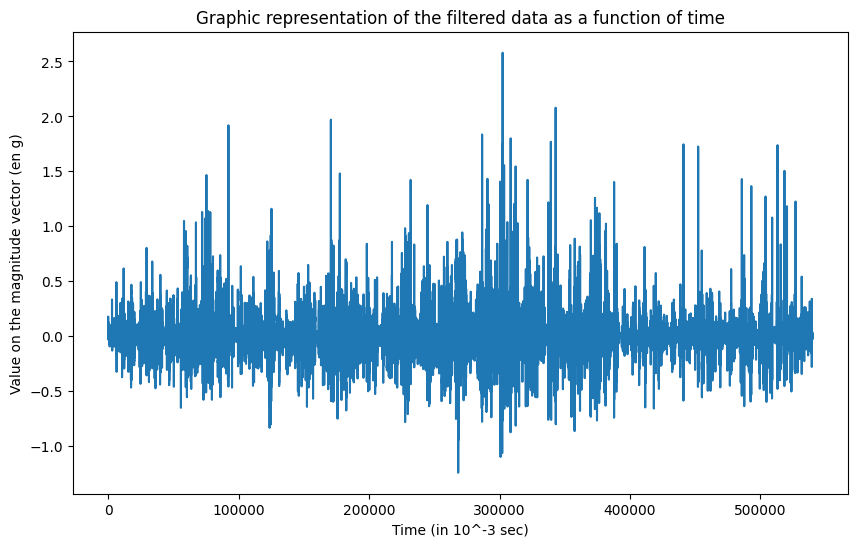

In [26]:
x_axis_time = np.arange(len(filtered_signal))

#Display
plt.figure(figsize=(10, 6))
#plt.subplot(1, 2, plot_idx)
plt.plot(x_axis_time, filtered_signal)
plt.xlabel("Time (in 10^-3 sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the filtered data as a function of time")   
plt.show()


TO DO -> Valeur absolue

TO DO -> Group data by 1s epochs (instead of 10ms)

In [58]:
filtered_compressed_signal_df = {}

for name in filtered_signal_df.keys():
    signal = filtered_signal_df[name]
    print(signal)
    #Zero padding to allow the reshaping
    signal_len = len(signal)
    to_complete = signal_len % 10
    if to_complete != 0:
        padding = 10 - to_complete
        padded_signal = np.pad(signal, (0, padding), mode='constant')
    else:
        padded_signal = signal

    # Reshape in 100 samples epoch (1s epoch)
    reshaped_signal = padded_signal.reshape(-1, 100)

    # Sum of the magnitude vector for every 1s epoch = activity count
    filtered_compressed_signal_df[name] = np.sum(reshaped_signal, axis=1)


print(filtered_compressed_signal_df)
#print(activity_count_1s[25:35])

"""
#Display
x_axis_time = np.arange(len(activity_count_1s))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, activity_count_1s)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the filtered data as a function of time")   
plt.show()
"""


[0.0071170183907532875 0.004459915104757072 0.0018055922624252113 ...
 0.01011688684537004 0.009295223369668431 0.008451364150543865]
[0.007987049058366388 0.007842876781621266 0.007765678634877607 ...
 0.002251642438303685 0.002031512029231299 0.0018205871326103706]
[0.00011519567139687856 0.0035725767598144428 0.007041715785317955 ...
 0.0013548348056118549 0.0013597190578858325 0.001336306389265685]
[0.0017284398636098586 0.008646683432155218 0.015552390562217399 ...
 0.015130284424421313 0.013920166572478167 0.012694214598613373]
[0.009918654695995701 0.013993779773321762 0.017993280336079474 ...
 0.011384059940572355 0.01040036382158284 0.00940824143664084]
[0.04140795250858009 0.046259688857028525 0.05124161879288734 ...
 0.03599200390744393 0.032977518209024115 0.029970523228137393]
{'left wrist_Accelerometer X': array([6.470140456113795, 4.73619472892889, 2.2825296165369244, ...,
       0.7459386580634845, 0.5050666018483113,
       np.float64(0.5980223856649213)], shape=(5400,

'\n#Display\nx_axis_time = np.arange(len(activity_count_1s))\nplt.figure(figsize=(10, 6))\nplt.plot(x_axis_time, activity_count_1s)\nplt.xlabel("Time (in sec)")\nplt.ylabel("Value on the magnitude vector (en g)")\nplt.title(f"Graphic representation of the filtered data as a function of time")   \nplt.show()\n'

Calculating VM

In [77]:
activity_counts = {"left" : [], 
        "right" : []}

#Browse every ligns (each period)
for idx_time in range (len(filtered_compressed_signal_df["left wrist_Accelerometer X"])):

    #Initialization to separate left sensor from right sensor
    idx_sensor = 0
    sum_left = 0
    sum_right = 0

    #Browse every axes
    for axis in filtered_compressed_signal_df.keys():

        if idx_sensor <= 2:
            sum_left += np.square(filtered_compressed_signal_df[axis][idx_time])
        
        else:
            sum_right += np.square(filtered_compressed_signal_df[axis][idx_time])
        
        idx_sensor += 1

    activity_counts["left"].append(np.sqrt(sum_left))
    activity_counts["right"].append(np.sqrt(sum_right))
            
        

print(activity_counts)

{'left': [np.float64(9.967087984891467), np.float64(6.307138453722419), np.float64(3.1956470394451872), np.float64(2.8787152567374696), np.float64(2.2799671359039118), np.float64(2.5218305266183974), np.float64(3.7987479996880866), np.float64(3.9027730470176167), np.float64(3.438249190109885), np.float64(7.367300666876795), np.float64(5.085655613349539), np.float64(7.9888575314744115), np.float64(6.418970405551969), np.float64(3.7641126511166156), np.float64(6.472329896036689), np.float64(4.088922217852121), np.float64(1.1365291240478896), np.float64(2.556759933632492), np.float64(2.9060534084160072), np.float64(1.768862301129071), np.float64(2.8841476032940654), np.float64(10.929299657339877), np.float64(11.139833960754054), np.float64(4.1467544710452), np.float64(8.040961933269594), np.float64(4.159469967567816), np.float64(6.794291282724494), np.float64(6.2301428391514175), np.float64(8.971081718682887), np.float64(25.435566848038565), np.float64(16.965169941719253), np.float64(10.4

Display activity count per 1s

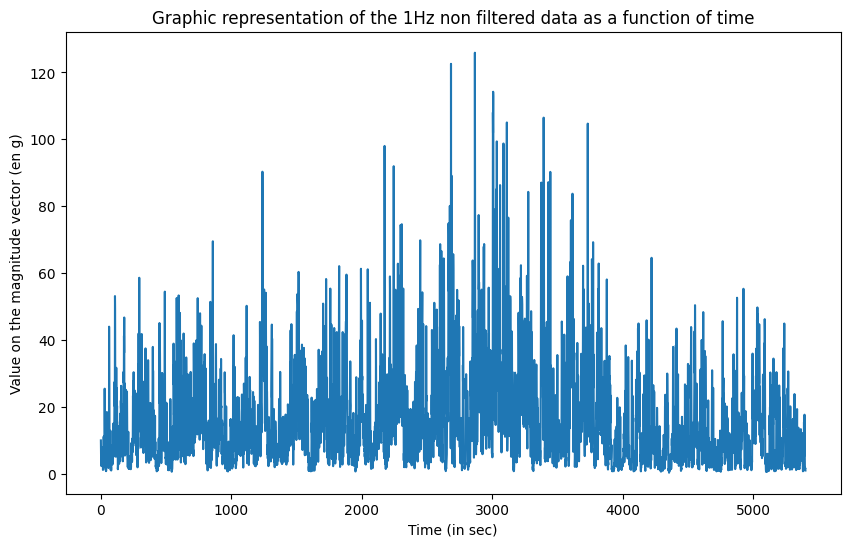

In [79]:
#Display
x_axis_time = np.arange(len(activity_counts["left"]))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time,activity_counts["left"])
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the 1Hz non filtered data as a function of time")   
plt.show()

In [29]:
"""Grouping by :
1. CALCULATE VM for each 0.01 period
2. GROUP 0.01S EPOCHS IN 1S EPOCH (sum of the VM)

--> Method in Peach article
"""


#Dictonary saving activity counts for left wrist sensor [0] and right wrist sensor [1]
activity_counts = []

#Dictonary saving mean activity counts for left wrist sensor [0] and right wrist sensor [1]
mean_activity_counts = []

#Browse data from the various sensors
for sensor_data in lst_sensors:

    activity_count_idx = 0
    #Dictonary saving activity counts for the sensor_data (left for the first loop lap, right for the second loop lap)
    activity_counts_sensor = []
    #Variable storing acceleration intensity for a 1 sec epoch
    sum_norm = 0

    for data_idx in range(len(sensor_data)): 
        #Magnitude vector for each 0.01s epoch
        norm = np.sqrt(sensor_data['Accelerometer X'][data_idx]**2 + sensor_data['Accelerometer Y'][data_idx]**2 + sensor_data['Accelerometer Z'][data_idx]**2)
            
        #Group 10ms epoch in 1s epoch and save the sum of intensities
        if activity_count_idx < 100:
            sum_norm += norm
            activity_count_idx += 1
        else:
            #Update activity_counts
            activity_counts_sensor.append(sum_norm.item())
            activity_count_idx = 1
            sum_norm = 0
    
    activity_counts.append(activity_counts_sensor) 
    mean_activity_counts.append((np.mean(activity_counts_sensor)).item())

print("\n*** Left wrist ***")
print(f"Mean activity count 1s epoch : {mean_activity_counts[0]}")
print(f"Sampling of activity count : {activity_counts[0][25:35]}")
print("\n*** Right wrist ***")
print(f"Mean activity count 1s epoch : {mean_activity_counts[1]}")
print(f"Sampling of activity count : {activity_counts[1][25:35]}")

#Magnitude ratio
magn_ratio = math.log(mean_activity_counts[1]/mean_activity_counts[0])

print(f"Magnitude ratio : {magn_ratio}")

KeyboardInterrupt: 

In [ ]:
"""CALCULATING ACTIVITY COUNTS
1. GROUP 0.01S EPOCHS IN 1S EPOCH
2. CALCULATE VM (ACTIVITY COUNT)"""
import math

#Dictonary saving activity counts for left wrist sensor [0] and right wrist sensor [1]
activity_counts = []

#Dictonary saving mean activity counts for left wrist sensor [0] and right wrist sensor [1]
mean_activity_counts = []

#Browse data from the various sensors
for sensor_data in lst_sensors:

    activity_count_idx = 0
    #Dictonary saving activity counts for the sensor_data (left for the first loop lap, right for the second loop lap)
    activity_counts_sensor = []
    #Variable storing acceleration intensity for a 1 sec epoch for each axis
    sum_x, sum_y, sum_z = 0, 0, 0

    for data_idx in range(len(sensor_data)): 

        #Group 10ms epoch in 1s epoch and save the sum of intensities
        if activity_count_idx < 100:
            sum_x  += sensor_data['Accelerometer X'][data_idx] 
            sum_y += sensor_data['Accelerometer Y'][data_idx] 
            sum_z += sensor_data['Accelerometer Z'][data_idx]
            activity_count_idx += 1
        else:
            #Magnitude vector for each 1s epoch
            norm = np.sqrt(sum_x**2 + sum_y**2 + sum_z**2)

            #Update activity_counts
            activity_counts_sensor.append(norm.item())
            activity_count_idx = 1
            sum_x, sum_y, sum_z = 0, 0, 0

    #Saving the metrics for the sensor_data 
    activity_counts.append(activity_counts_sensor) 
    mean_activity_counts.append((np.mean(activity_counts_sensor)).item())
        
print("\n*** Left wrist ***")
print(f"Mean activity count 1s epoch : {mean_activity_counts[0]}")
print(f"Sampling of activity count : {activity_counts[0][25:35]}")
print("\n*** Right wrist ***")
print(f"Mean activity count 1s epoch : {mean_activity_counts[1]}")
print(f"Sampling of activity count : {activity_counts[1][25:35]}")





*** Left wrist ***
Mean activity count 1s epoch : 90.6794623549431
Sampling of activity count : [67.30599468651126, 64.71865484782391, 68.1212408998229, 71.52904273891936, 97.04629778377871, 82.78133657545368, 63.88785986927818, 62.19869263632644, 65.15794177994552, 68.07923863384342]

*** Right wrist ***
Mean activity count 1s epoch : 108.02681177686554
Sampling of activity count : [50.36385201808893, 111.81337791367206, 101.23138572172235, 87.64400837028073, 82.44496329918762, 81.15905380128, 78.37889131463768, 67.20705374108684, 66.19876759317181, 66.42480406600215]
Magnitude ration np : -0.17504855692174862
Magnitude ratio math : -0.17504855692174862


Display of acceleration (every epoch) as a function of time

In [31]:
#Initialisation for subplot index
plot_idx = 1
lst_name_sensor = ["left sensor", "right sensor"]

for sensor_data in lst_sensors:

    #Initialization for x_axis
    time_idx = 0

    #Initialisation of the axis
    x_axis_time = []
    y_axis_norm = []

    #Display for left wrist sensor
    for data_idx in range(len(sensor_data)):

        #Magnitude vector for each 0.01s epoch
        norm = np.sqrt(sensor_data['Accelerometer X'][data_idx]**2 + sensor_data['Accelerometer Y'][data_idx]**2 + sensor_data['Accelerometer Z'][data_idx]**2)
        
        #Add new values to the axis
        x_axis_time.append(time_idx)
        y_axis_norm.append(norm)

        time_idx += 1

    #Display
    plt.subplot(1, 2, plot_idx)
    plt.plot(x_axis_time, y_axis_norm)
    plt.xlabel("Time (in 10^-3 sec)")
    plt.ylabel("Value on the magnitude vector (en g)")
    plt.title(f"Activity counts of {lst_name_sensor[plot_idx-1]} as a function of 0.01s epoch time")

    plot_idx += 1

   
plt.show()


KeyboardInterrupt: 

A scaling is then applied to convert the acceleration signal into a metric referred to as activity counts. The scaling is 1 count = 0.001664 g
-> pas besoin c'est dejà fait dans la transformation de .gt3x en .csv

Active duration : sum of all the sampling where a mouvement is detected (VM > 1) for 1 limb

and

Activity count : sum of the intensities (VM) for each 1s period (group 100 sampling together) for 1 limb

In [ ]:
"""CALCULATING ACTIVITY COUNTS
1. CALCULATE VM 
2. GROUP 0.01S EPOCHS IN 1S EPOCH (ACTIVITY COUNT)
"""

#Dictonary saving active duration for left wrist sensor [0] and right wrist sensor [1]
active_duration = []

#Dictonary saving activity counts for left wrist sensor [0] and right wrist sensor [1]
activity_counts = []

#Dictonary saving mean activity counts for left wrist sensor [0] and right wrist sensor [1]
mean_activity_counts = []

#Browse data from the various sensors
for sensor_data in lst_sensors:

    #Initialisation of active duration for the selected left or right sensor : count of every 0.01s epoch where a mouvement is detected
    sensor_active_duration = 0

    activity_count_idx = 0
    #Dictonary saving activity counts for the sensor_data (left for the first loop lap, right for the second loop lap)
    activity_counts_sensor = []
    #Variable storing acceleration intensity for a 1 sec epoch
    sum_norm = 0

    #Initialization for the mean activity count
    activity_count_60s = 0
    sum_mean = 0
    mean_activity_counts_sensor = []

    for data_idx in range(len(sensor_data)): 
        #Magnitude vector for each 0.01s epoch
        norm = np.sqrt(sensor_data['Accelerometer X'][data_idx]**2 + sensor_data['Accelerometer Y'][data_idx]**2 + sensor_data['Accelerometer Z'][data_idx]**2)

        #Epochs active's classification 
        if norm > 1:
            #Update active duration
            sensor_active_duration += 1
            
        #Group 10ms epoch in 1s epoch and save the sum of intensities
        if activity_count_idx < 100:
            sum_norm += norm
            activity_count_idx += 1
        else:
            #Update activity_counts
            activity_counts_sensor.append(sum_norm)
            activity_count_idx = 1
            sum_norm = 0

        """
        #Group 10ms epoch in 60s epoch and save the sum of intensities
        if activity_count_60s < 6000:
            sum_mean += norm
            activity_count_60s += 1
        else:
            #Update activity_counts
            mean_activity_counts_sensor.append(sum_mean)
            activity_count_60s = 1
            sum_mean = 0
        """
    #Saving the metrics for the sensor_data
    active_duration.append(sensor_active_duration) 
    activity_counts.append(activity_counts_sensor) 
    mean_activity_counts.append((np.mean(activity_counts_sensor)))
    

#Active left duration ratio : left_active_duration / (total duration*100)
left_active_duration_ratio = active_duration[0] / ((len(data_left_wrist)-1)) * 100
#Active right duration ratio : right_active_duration / (total duration*100)
right_active_duration_ratio = active_duration[1] / ((len(data_right_wrist)-1)) * 100

#Calculation of the mean activity count : mean of activity counts per second over the entire monitoring period

#mean_activity_count = np.mean(activity_counts_60s[1])/len(sensor_data)

print("\n*** Left wrist ***")
print(f"Active duration : {active_duration[0]} hundredth of a second")
print(f"Active duration ratio : {left_active_duration_ratio} %")
print(f"Mean activity count 1s epoch : {mean_activity_counts[0]}")
print(f"Sampling of activity count : {activity_counts[0][25:35]}")
print("\n*** Right wrist ***")
print(f"Active duration : {active_duration[1]} hundredth of a second")
print(f"Active duration ratio : {right_active_duration_ratio} %")
print(f"Mean activity count 1s epoch : {mean_activity_counts[1]}")
print(f"Sampling of activity count : {activity_counts[1][25:35]}")


*** Left wrist ***
Active duration : 229084 hundredth of a second
Active duration ratio : 42.42312008562995 %
Mean activity count 1s epoch : 93.85521824964955
Sampling of activity count : [np.float64(67.51607146927813), np.float64(65.24223943956281), np.float64(68.16382701545605), np.float64(71.5756973345222), np.float64(97.87698347033272), np.float64(83.70981408729048), np.float64(63.91077241430251), np.float64(63.09131754123263), np.float64(65.22366655605936), np.float64(68.08951461593836)]

*** Right wrist ***
Active duration : 342693 hundredth of a second
Active duration ratio : 63.461901710747085 %
Mean activity count 1s epoch : 113.45254568746516
Sampling of activity count : [np.float64(105.97180783990945), np.float64(112.07426064969461), np.float64(102.60979989011031), np.float64(89.25889408140708), np.float64(82.60984660115926), np.float64(81.55144745204174), np.float64(78.70689206685222), np.float64(67.94338089768888), np.float64(66.20670364944301), np.float64(66.426685256149

[68.25490501 65.94175688 68.84173231 72.31320638 98.63211459 84.80788296
 64.55814331 63.73206338 65.86880518 68.76974824]


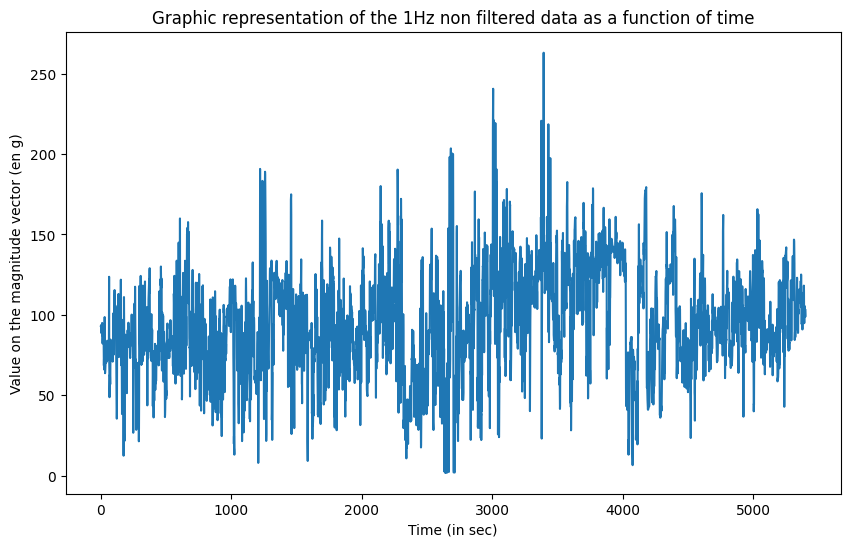

In [42]:
#Zero padding to allow the reshaping
signal_len = len(data_left_wrist['Norm'])
to_complete = signal_len % 10
if to_complete != 0:
    padding = 10 - to_complete
    padded_signal = np.pad(data_left_wrist['Norm'], (0, padding), mode='constant')
else:
    padded_signal_ = data_left_wrist['Norm']

# Reshape in 100 samples epoch (1s epoch)
reshaped_signal = padded_signal.reshape(-1, 100)

# Sum of the magnitude vector for every 1s epoch = activity count
activity_count_1s = np.sum(reshaped_signal, axis=1)

print(activity_count_1s[25:35])

#Display
x_axis_time = np.arange(len(activity_count_1s))
plt.figure(figsize=(10, 6))
plt.plot(x_axis_time, activity_count_1s)
plt.xlabel("Time (in sec)")
plt.ylabel("Value on the magnitude vector (en g)")
plt.title(f"Graphic representation of the 1Hz non filtered data as a function of time")   
plt.show()



Display of the activity count per 1s epoch for the right sensor

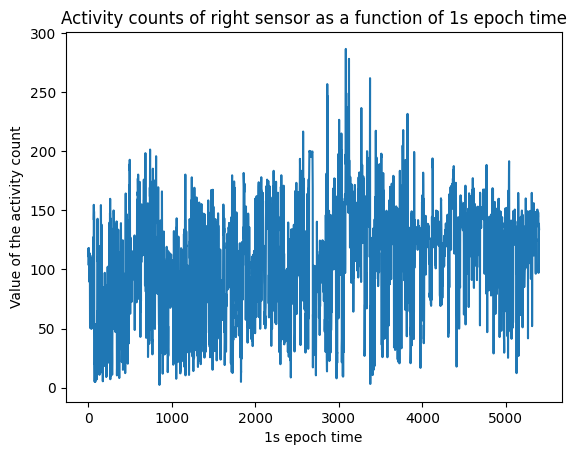

In [85]:
x_axis_1s_epoch = []
y_axis_activity_count = activity_counts[1]

for time_idx in range (int(len(data_right_wrist) / 100)):
    x_axis_1s_epoch.append(time_idx)

#Display
plt.plot(x_axis_1s_epoch, y_axis_activity_count)
plt.xlabel("1s epoch time")
plt.ylabel("Value of the activity count")
plt.title("Activity counts of right sensor as a function of 1s epoch time")
plt.show()

Use ratio : ratio of activity time of affected member to activity time of non affected member (or activity counts instead of activity time)

In [86]:
use_ratio = active_duration[0] / active_duration[1]

print(f"Use ratio : {use_ratio}")

Use ratio : 0.668481702281634


Magnitude ratio

In [87]:
#Magnitude ratio
magnitude_ratio = np.log(mean_activity_counts[0]/mean_activity_counts[1]) 

print(f"Magnitude ration np : {magnitude_ratio}")

Magnitude ration np : -0.17504855692174862
